In [3]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

# 1. 패키지로드 & 한글설정 & 경고메세지 ignore

In [4]:
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 시각화의 선명도를 높임
%config InlineBackend.figure_format = "retina"
# from IPython.display import set_matplotlib_formats
# set_matplotlib_formats('retina')

# 다른 폰트를 기본으로 하려면
# from matplotlib.font_manager import FontProperties, fontManager
# font_path = 'data/font/온글잎밑미.ttf'
# #font_path = "c:/Windows/Fonts/H2PORM.TTF"
# fontproperties = FontProperties(fname=font_path, size=30)
# fontManager.addfont(file_path) # windows폴더에 있지 않는 ttf파일일 경우 
# font_name = fontproperties.get_name()

# 한글설정 및 미적속성 설정
sns.set(style='white',
       context='notebook',
       palette='Dark2',
       rc={'figure.figsize': (12,3),
           'font.family':'Malgun Gothic',
           # font.family':font_name,
           #'font.size':20,
           'axes.unicode_minus':False})

# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='ignore') # 경고 메세지 안보이게
# warnings.filterwarnings(action='default') # 경고 메세지 보이게

In [5]:
df = pd.read_csv('c:/ai/downloads/shareData/상가정보/서울부산상가정보백업.csv')
df.shape

(692592, 17)

In [6]:
df_academy = pd.read_csv('c:/ai/downloads/shareData/상가정보/ch13_df_academy.csv')
df_academy.shape

(45080, 17)

# 13.	구별로 학원수 비교 : 서울 대치동이나 목동에 사교육이 발달되었다는 가설을 뒷받침할 수 있는 분석
## ① 서울시 교육(상권업종대분류명 이용) 데이터를 df_academy 변수에 할당하고 확인


In [204]:
df['상권업종대분류명'].unique()

array(['부동산', '음식', '시설관리·임대', '예술·스포츠', '소매', '과학·기술', '수리·개인', '보건의료',
       '숙박', '교육'], dtype=object)

In [214]:
df_academy = df[(df['상권업종대분류명']=='교육') & (df['시도명']=='서울특별시')].copy(
                                                                        # deep=True
                                                                   )
df_academy.shape
# df_academy를 수정할 경우 .copy() 깊은 복사 함수로 추출 warning 출력 안 됨

(45080, 17)

In [216]:
df_academy.to_csv('c:/ai/downloads/shareData/상가정보/ch13_df_academy.csv', index=False)

## ②	df_academy 데이터 셋을 상호명별로 빈도수 출력(value_counts()함수 이용하거나 groupby이용)

In [220]:
df_academy['상호명'].value_counts()

입시·교과학원          280
업소명없음             47
그외기타교육기관          38
예리엘잉글리쉬           22
한우리독서토론논술         16
                ... 
한국방과후교육연구회         1
에프아이비즈니스아카데미주      1
이디엠글로벌캠퍼스          1
알앤지유나이티드주          1
씨올다앤 주식회사          1
Name: 상호명, Length: 41221, dtype: int64

## ③ df_academy 데이터 셋을 상호명별로 빈도수 상위 10개 출력

In [225]:
df_academy['상호명'].value_counts().head(10)
df_academy['상호명'].value_counts()[:10]
df_academy['상호명'].value_counts().iloc[:10]

입시·교과학원      280
업소명없음         47
그외기타교육기관      38
예리엘잉글리쉬       22
한우리독서토론논술     16
개인과외          16
음악학원          15
모던필라테스        14
아메리카요가        11
용인대태권도        11
Name: 상호명, dtype: int64

## ④ df_academy 데이터 셋을 시군구명 별로 빈도수 출력(학원이 가장 많은 구부터 출력)

In [227]:
# df_academy.groupby('시군구명')['상호명'].count()
df_academy['시군구명'].value_counts()

강남구     6218
서초구     3816
송파구     3137
마포구     2619
양천구     2516
강서구     2275
강동구     2046
노원구     2016
영등포구    1815
성북구     1667
은평구     1561
관악구     1554
광진구     1387
동작구     1386
서대문구    1338
구로구     1310
동대문구    1272
성동구     1183
종로구     1058
중랑구      970
도봉구      899
용산구      871
금천구      828
강북구      762
중구       576
Name: 시군구명, dtype: int64

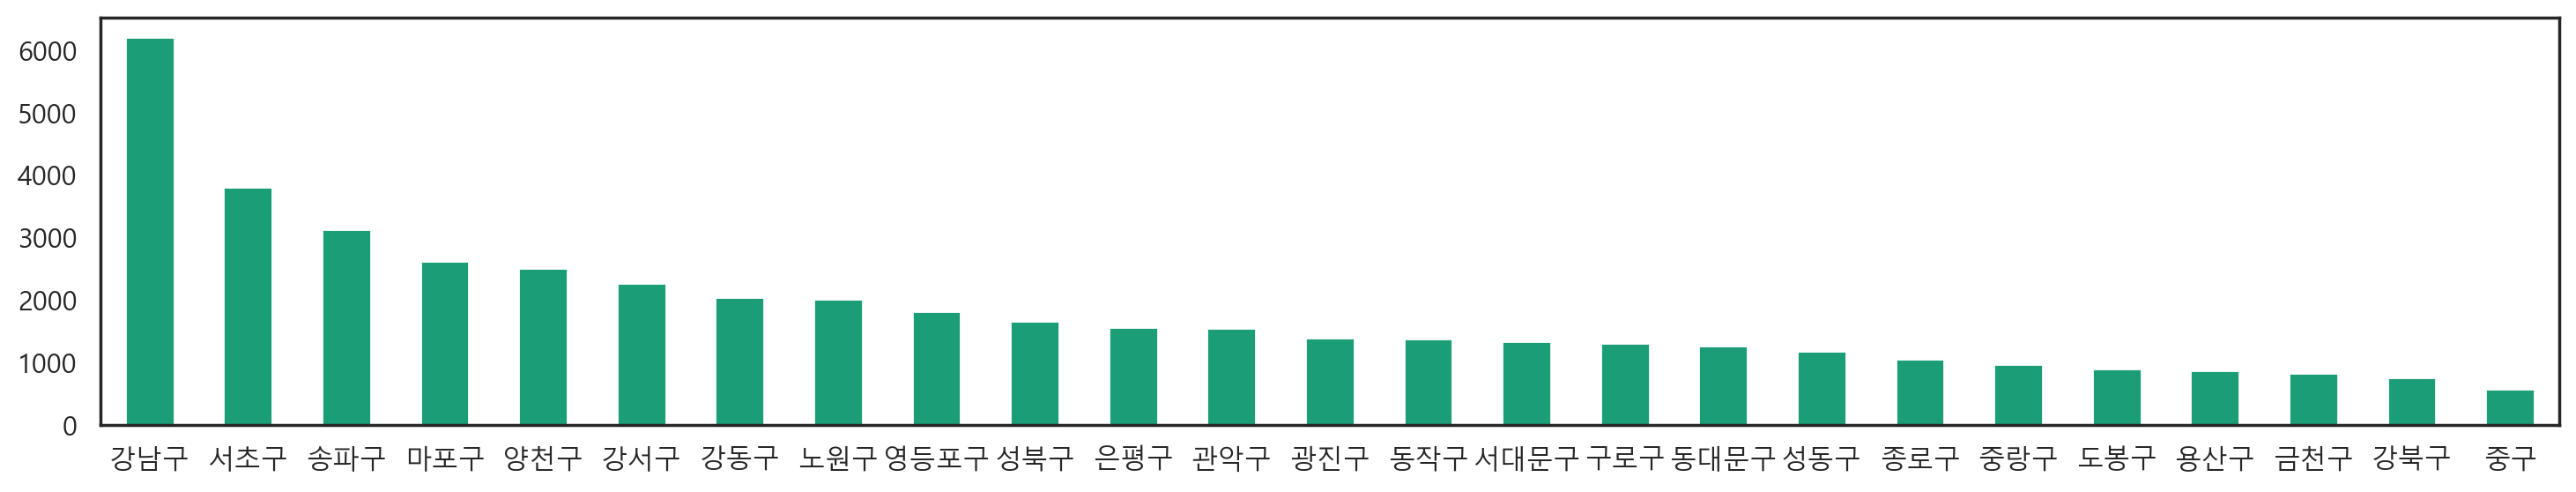

In [230]:
df_academy['시군구명'].value_counts().plot(kind='bar', rot=0)
plt.show()

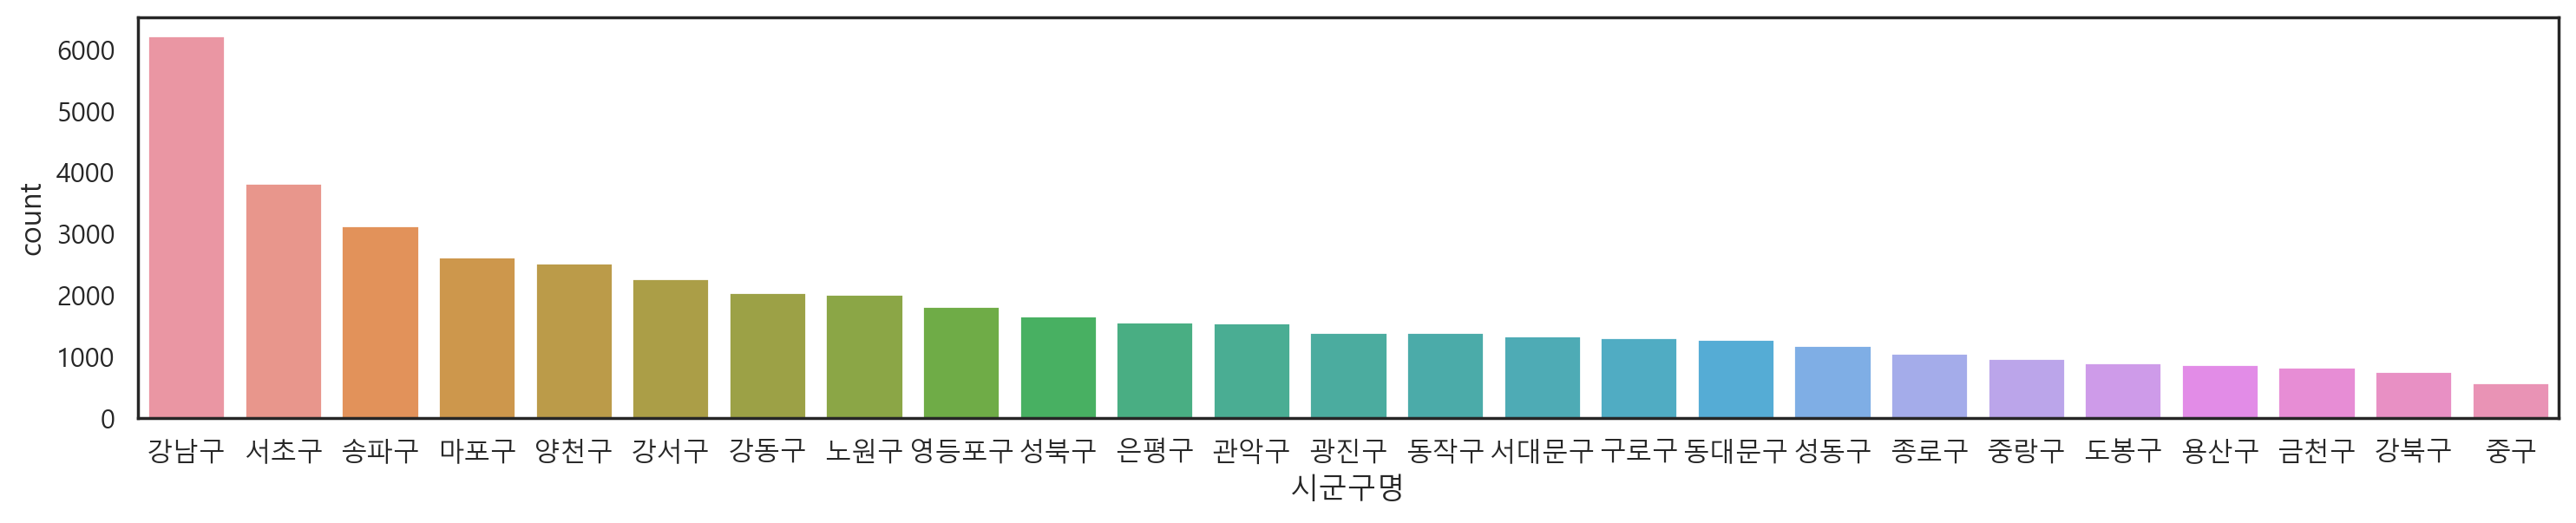

In [233]:
sns.countplot(data=df_academy,
             x='시군구명',
             order=df_academy['시군구명'].value_counts().index)
plt.show()

## ⑤df_academy 데이터 셋에서 어떤 종류의 학원들이 많은지 상위10개만 academy_count변수에 할당하고 출력(상권업종소분류명 컬럼 이용)

In [237]:
group = df_academy.groupby(['상권업종중분류명','상권업종소분류명'])
for (medium, sub), val in group:
    print(medium, ' => ',sub)

교육 지원  =>  교육컨설팅업
교육 지원  =>  기타 교육지원 서비스업
기타 교육  =>  그 외 기타 교육기관
기타 교육  =>  기타 기술/직업 훈련학원
기타 교육  =>  기타 예술/스포츠 교육기관
기타 교육  =>  레크리에이션 교육기관
기타 교육  =>  미술학원
기타 교육  =>  사회교육시설
기타 교육  =>  외국어학원
기타 교육  =>  요가/필라테스 학원
기타 교육  =>  운전학원
기타 교육  =>  음악학원
기타 교육  =>  전문자격/고시학원
기타 교육  =>  직원 훈련기관
기타 교육  =>  청소년 수련시설
기타 교육  =>  컴퓨터 학원
기타 교육  =>  태권도/무술학원
일반 교육  =>  입시·교과학원


In [21]:
df_academy.to_csv('c:/ai/downloads/shareData/상가정보/ch13_df_academy.csv', index=False)

In [23]:
df_academy = pd.read_csv("c:/ai/downloads/shareData/상가정보/ch13_df_academy.csv")
df_academy.shape

(45080, 17)

In [24]:
# 어떤 종류의 학원이 있는지(= 어떤 상권업종소분류명)
print(df_academy['상권업종소분류명'].unique())
print(len(df_academy['상권업종소분류명'].unique()))
print(df_academy['상권업종소분류명'].nunique())

['입시·교과학원' '음악학원' '태권도/무술학원' '요가/필라테스 학원' '미술학원' '교육컨설팅업' '전문자격/고시학원'
 '기타 기술/직업 훈련학원' '청소년 수련시설' '사회교육시설' '직원 훈련기관' '기타 예술/스포츠 교육기관'
 '기타 교육지원 서비스업' '그 외 기타 교육기관' '외국어학원' '운전학원' '레크리에이션 교육기관' '컴퓨터 학원']
18
18


In [8]:
# 상권업종소분류명별 빈도수(빈도수가 상위 10개)
df_academy['상권업종소분류명'].value_counts().head(10)
df_academy['상권업종소분류명'].value_counts().iloc[:10]
academy_count = df_academy['상권업종소분류명'].value_counts()[:10]
academy_count

입시·교과학원          17123
요가/필라테스 학원        4955
음악학원              3907
기타 기술/직업 훈련학원     2890
기타 교육지원 서비스업      2688
미술학원              2512
태권도/무술학원          2227
그 외 기타 교육기관       1944
교육컨설팅업            1784
외국어학원             1262
Name: 상권업종소분류명, dtype: int64

## ⑥ df_academy 데이터셋에서 상권업종소분류명별로 빈도수를 구했을 때 빈도가 1000이상인 데이터만 따로 academy_count_1000변수에 할당

In [25]:
academy_count = df_academy['상권업종소분류명'].value_counts()
academy_count_1000 = academy_count[academy_count>1000]
academy_count_1000

입시·교과학원           17123
요가/필라테스 학원         4955
음악학원               3907
기타 기술/직업 훈련학원      2890
기타 교육지원 서비스업       2688
미술학원               2512
태권도/무술학원           2227
그 외 기타 교육기관        1944
교육컨설팅업             1784
외국어학원              1262
기타 예술/스포츠 교육기관     1200
Name: 상권업종소분류명, dtype: int64

In [26]:
academy_count_1000.index

Index(['입시·교과학원', '요가/필라테스 학원', '음악학원', '기타 기술/직업 훈련학원', '기타 교육지원 서비스업',
       '미술학원', '태권도/무술학원', '그 외 기타 교육기관', '교육컨설팅업', '외국어학원', '기타 예술/스포츠 교육기관'],
      dtype='object')

In [27]:
# 소분류가 academy_count_1000인 행만 추출
top1000 = df_academy[df_academy['상권업종소분류명'].isin(academy_count_1000.index)]
top1000.shape

(42492, 17)

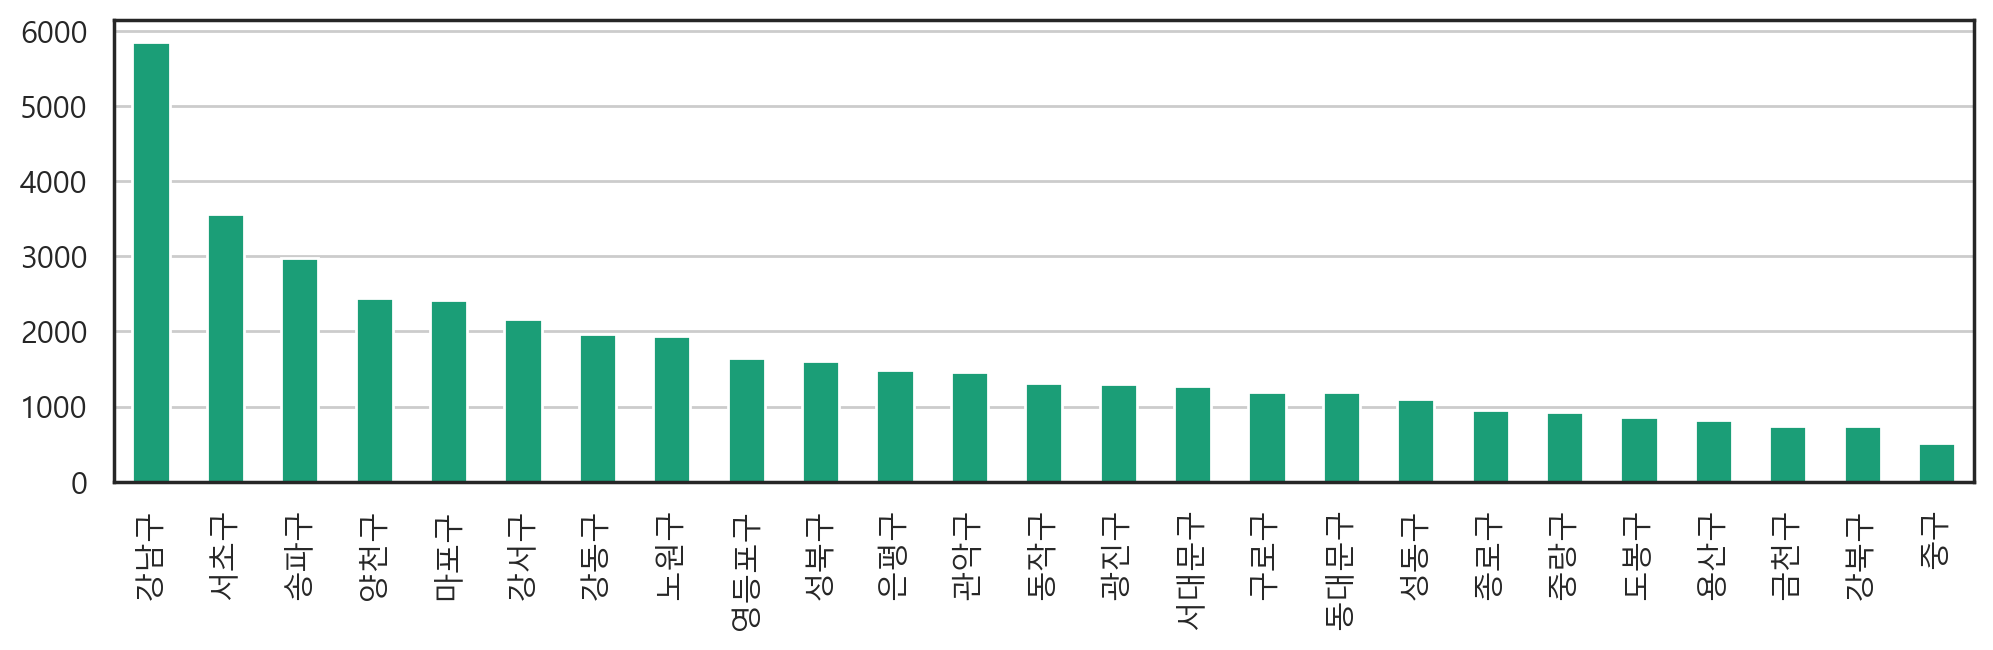

In [30]:
# 구별 학원(top1000) 수 비교
top1000['시군구명'].value_counts()
top1000['시군구명'].value_counts().plot(kind='bar')
plt.grid(axis='y')
plt.show()

## ⑦ df_academy 데이터셋을 “시군구명”, "상권업종소분류명” 별 상호명 빈도수를 academy_group 변수에 할당 출력

In [31]:
academy_group = df_academy.groupby(['시군구명','상권업종소분류명'])['상호명'].count()
academy_group

시군구명  상권업종소분류명      
강남구   교육컨설팅업            467
      그 외 기타 교육기관       294
      기타 교육지원 서비스업      622
      기타 기술/직업 훈련학원     319
      기타 예술/스포츠 교육기관    157
                       ... 
중랑구   전문자격/고시학원           3
      직원 훈련기관             7
      청소년 수련시설            1
      컴퓨터 학원              4
      태권도/무술학원           74
Name: 상호명, Length: 445, dtype: int64

In [38]:
academy_group['강남구']

상권업종소분류명
교육컨설팅업             467
그 외 기타 교육기관        294
기타 교육지원 서비스업       622
기타 기술/직업 훈련학원      319
기타 예술/스포츠 교육기관     157
레크리에이션 교육기관         84
미술학원               292
사회교육시설              27
외국어학원              247
요가/필라테스 학원         700
운전학원                12
음악학원               307
입시·교과학원           2313
전문자격/고시학원           33
직원 훈련기관            136
청소년 수련시설            11
컴퓨터 학원              53
태권도/무술학원           144
Name: 상호명, dtype: int64

## ⑧ academy_group 데이터셋에서 강남구 데이터만 출력 및 시각화(barplot)

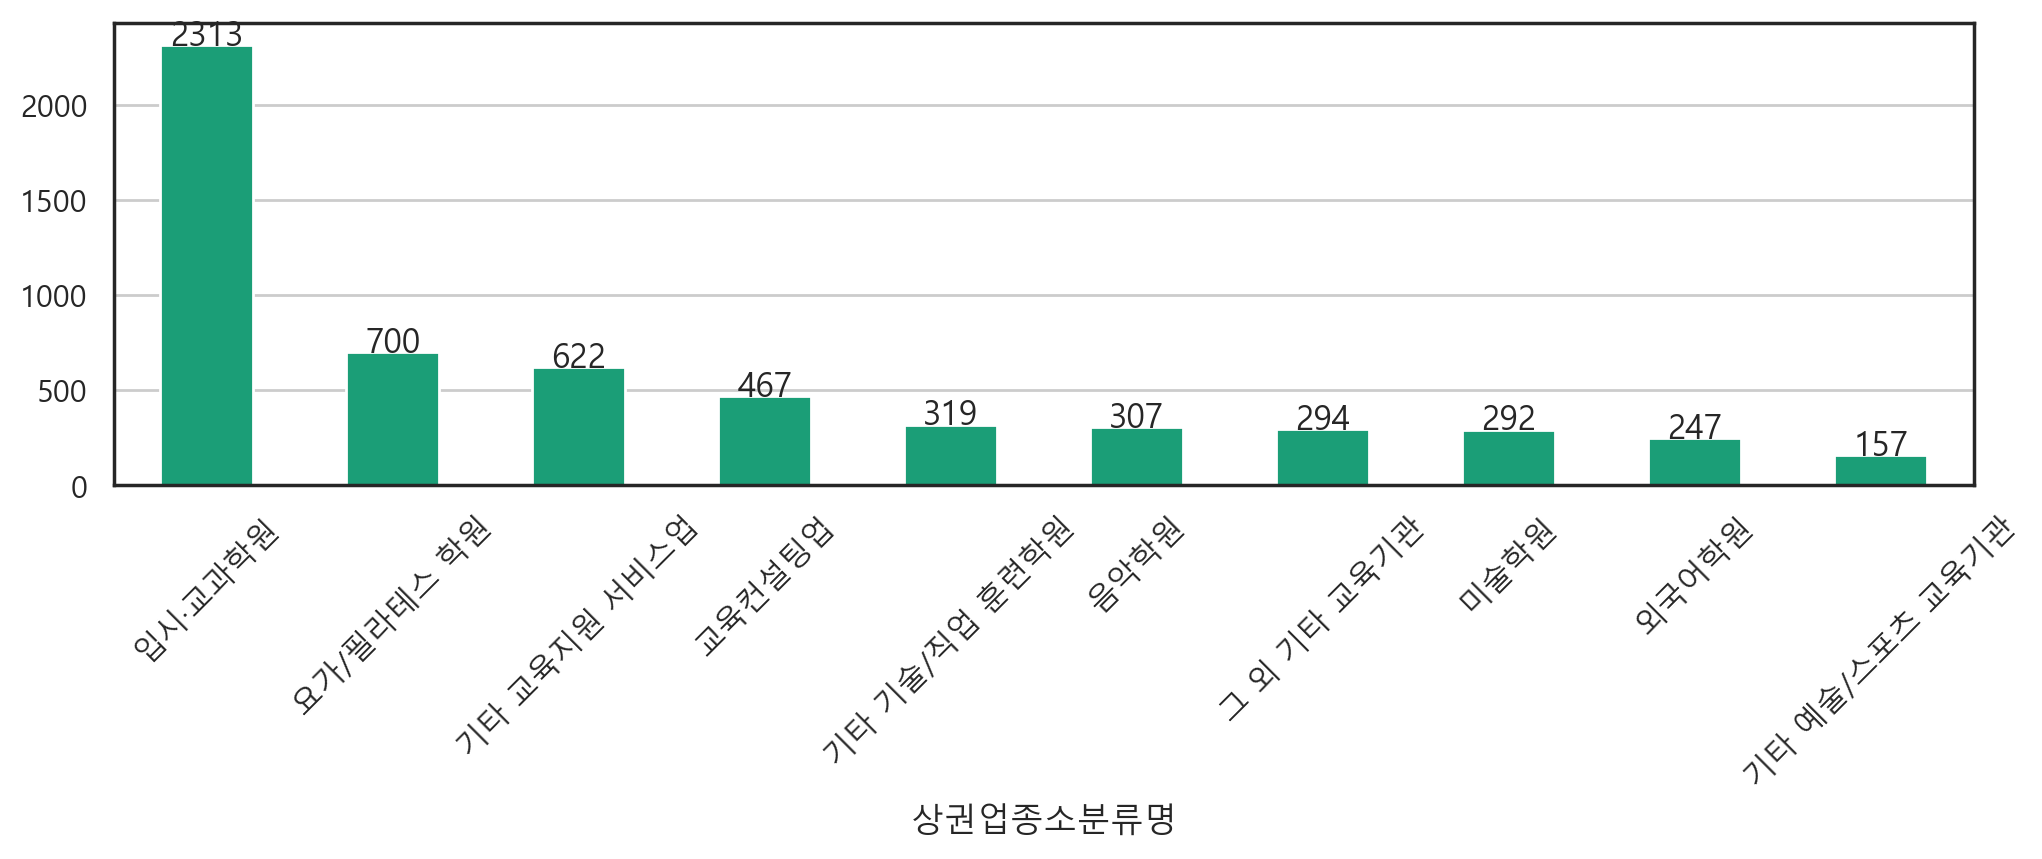

In [51]:
result = academy_group['강남구'].sort_values(ascending=False).head(10)
result.plot(kind='bar', rot=45)
for i, v in enumerate(result):
    plt.text(i, v, v, ha='center')
plt.grid(axis='y')
plt.show()

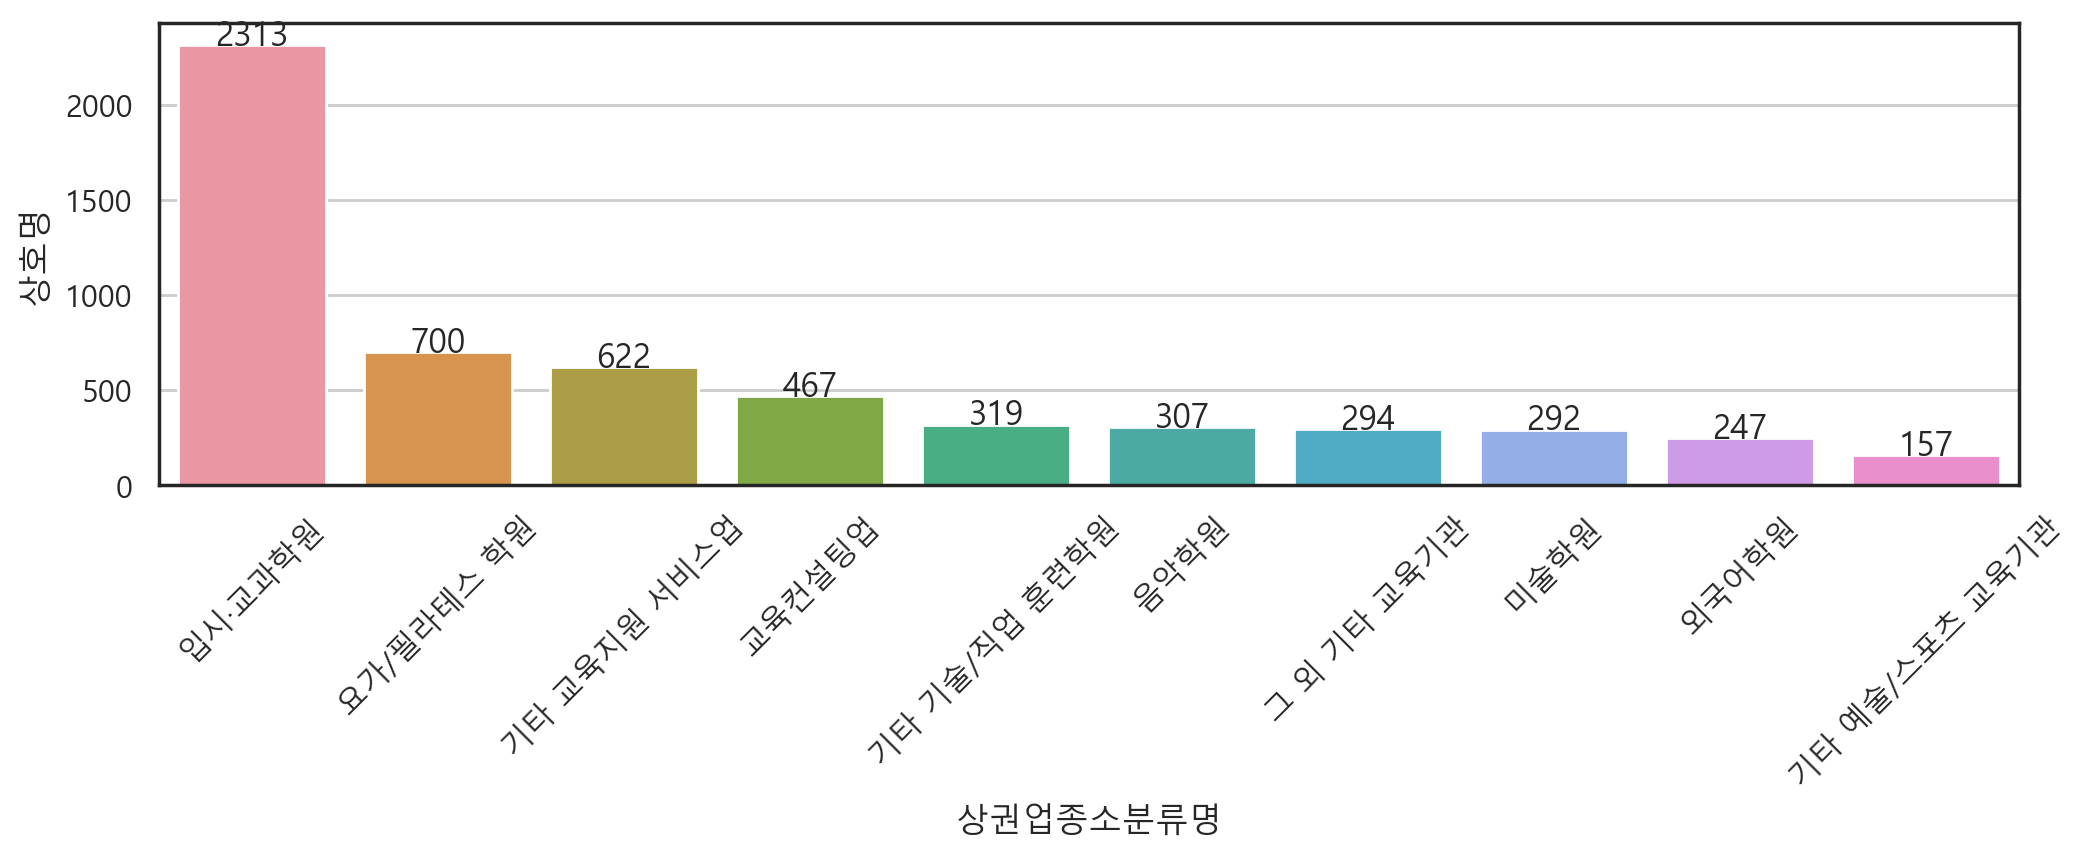

In [55]:
sns.barplot(x=result.index, y=result)
plt.xticks(rotation=45)
for i, v in enumerate(result):
    plt.text(i, v, v, ha='center')
plt.grid(axis='y')
plt.show()

## ⑨ df_academy데이터 중 “법정동명”컬럼이 “대치동”과 “목동”인 데이터만 가져와 상권업종소분류명별 빈도수 출력

In [64]:
# 대칭동에 많은 학원 종류
df_academy.loc[df_academy['법정동명']=='대치동', '상권업종소분류명'].value_counts()[:3]

입시·교과학원    1268
교육컨설팅업      130
미술학원         93
Name: 상권업종소분류명, dtype: int64

In [62]:
# 목동에 많은 학원 종류
df_academy.loc[df_academy['법정동명']=='목동', '상권업종소분류명'].value_counts()[:3]

입시·교과학원       711
음악학원           87
요가/필라테스 학원     83
Name: 상권업종소분류명, dtype: int64

In [71]:
# 대치동과 목동에 많은 학원 종류
top2 = df_academy.loc[df_academy['법정동명'].isin(['대치동','목동']), 
                      '상권업종소분류명'].value_counts().head(3)
top2 = top2.drop('요가/필라테스 학원')
top2

입시·교과학원    1979
교육컨설팅업      158
Name: 상권업종소분류명, dtype: int64

In [74]:
# df_academy에서 top2.index 소분류명만 추출
df_academy_sel = df_academy[df_academy['상권업종소분류명'].isin(top2.index)]
df_academy_sel.shape

(18907, 17)

In [76]:
# 입시관련 학원이 많은 법정동명
df_academy_sel['법정동명'].value_counts().head(10)

대치동    1398
목동      739
신정동     611
중계동     584
서초동     473
신사동     337
역삼동     336
봉천동     332
상계동     322
명일동     318
Name: 법정동명, dtype: int64

## ⑩“상권업종소분류명”별 "시군구명” 별 상호명 빈도수를 g변수에 할당하고 출력

In [83]:
g = df_academy.groupby(['상권업종소분류명','시군구명'])['상호명'].count()
g

상권업종소분류명  시군구명
교육컨설팅업    강남구     467
          강동구      35
          강북구      20
          강서구      53
          관악구      54
                 ... 
태권도/무술학원  용산구      33
          은평구     101
          종로구      28
          중구       19
          중랑구      74
Name: 상호명, Length: 445, dtype: int64

In [86]:
g['태권도/무술학원'].sort_values(ascending=False)

시군구명
강남구     144
송파구     143
강서구     135
양천구     133
노원구     133
강동구     125
서초구     115
성북구     115
관악구     109
은평구     101
구로구      90
영등포구     87
동작구      83
마포구      78
도봉구      77
강북구      76
동대문구     74
중랑구      74
광진구      72
서대문구     65
금천구      62
성동구      56
용산구      33
종로구      28
중구       19
Name: 상호명, dtype: int64

## ⑪ g변수의 내용중 "상권업종소분류명” 컬럼이 “입시·교과학원”데이터만 시각화(pandas의 plot.bar, pandas의 barh, seaborn의 barplot)

In [88]:
result = g['입시·교과학원'].sort_values(ascending=False)
result

시군구명
강남구     2313
양천구     1443
서초구     1235
송파구     1221
노원구     1057
강동구      961
강서구      912
성북구      775
마포구      768
은평구      679
동작구      586
관악구      568
서대문구     529
동대문구     527
광진구      499
영등포구     493
구로구      460
도봉구      398
중랑구      370
성동구      366
강북구      286
종로구      198
금천구      196
용산구      190
중구        93
Name: 상호명, dtype: int64

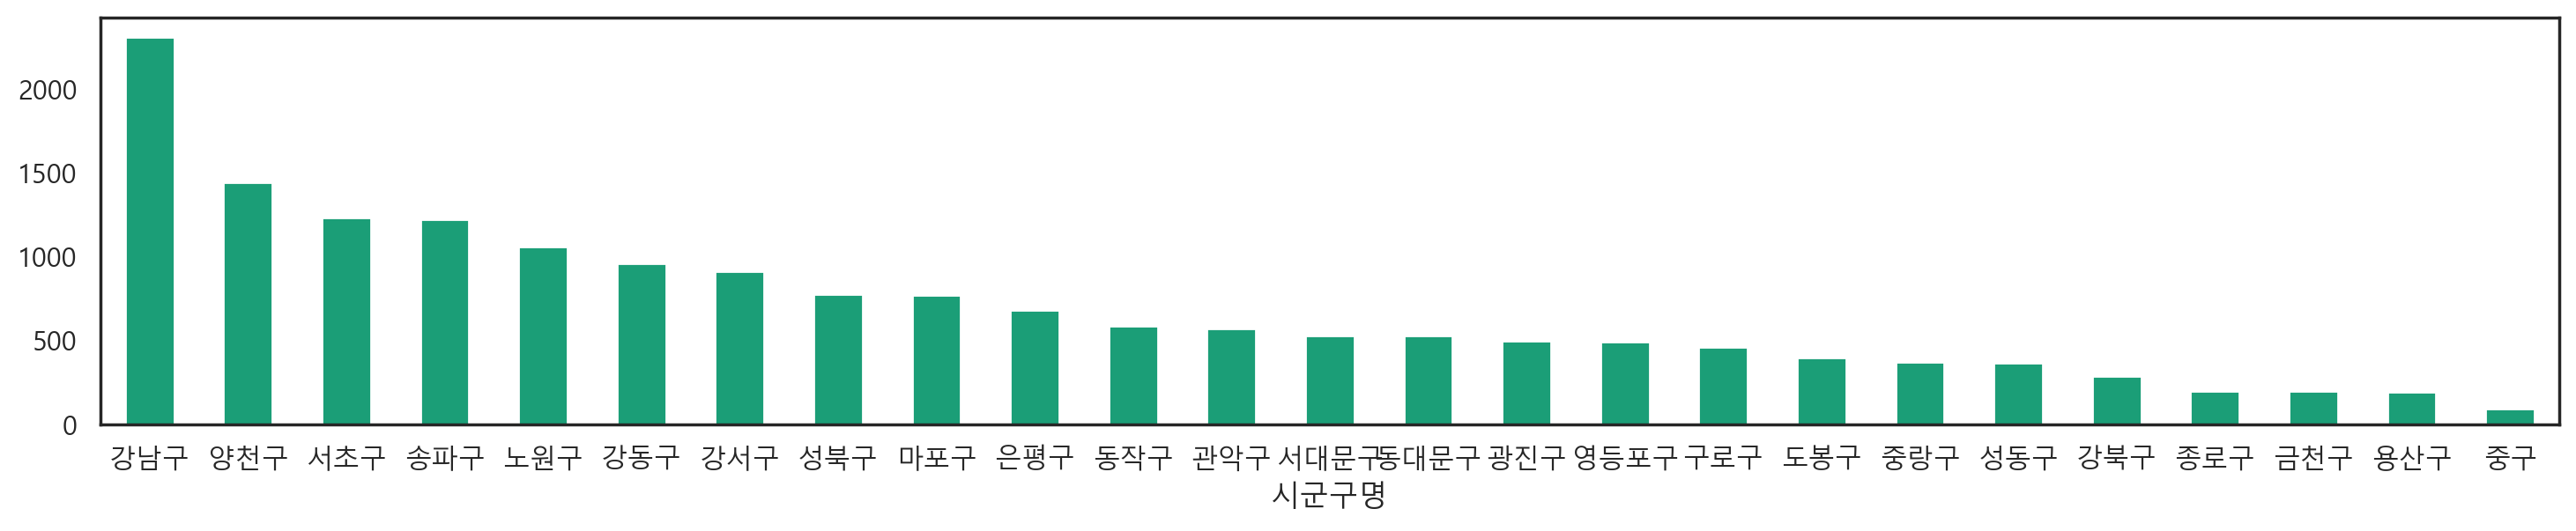

In [93]:
plt.figure(figsize=(18,3))
result.plot(kind='bar', rot=0)
plt.show()

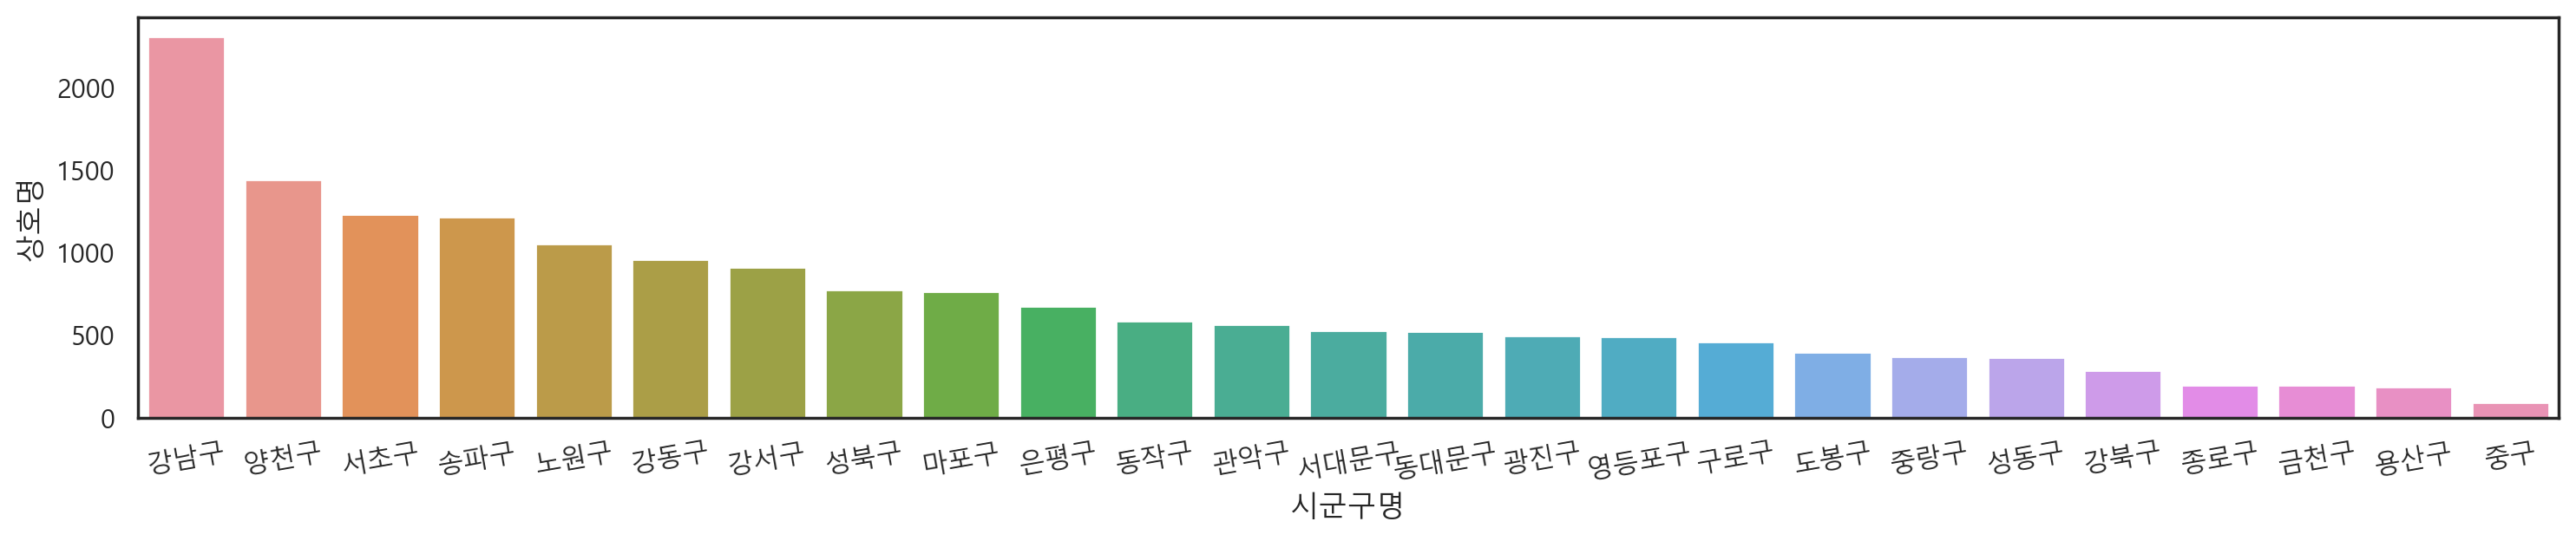

In [96]:
plt.figure(figsize=(18,3))
sns.barplot(x=result.index, y=result)
plt.xticks(rotation=10)
plt.show()

# 14. 서울시 데이터만 경도와 위도를 산점도로 시각화
## ① df_academy 데이터셋의 경도와 위도를 “시군명”별로 색상을 다르게 scatterplot으로 시각화


In [99]:
sns.set(style='white',
       context='notebook',
       palette='Dark2',
       rc={'figure.figsize': (10,6),
           'font.family':'Malgun Gothic',
           'axes.unicode_minus':False})

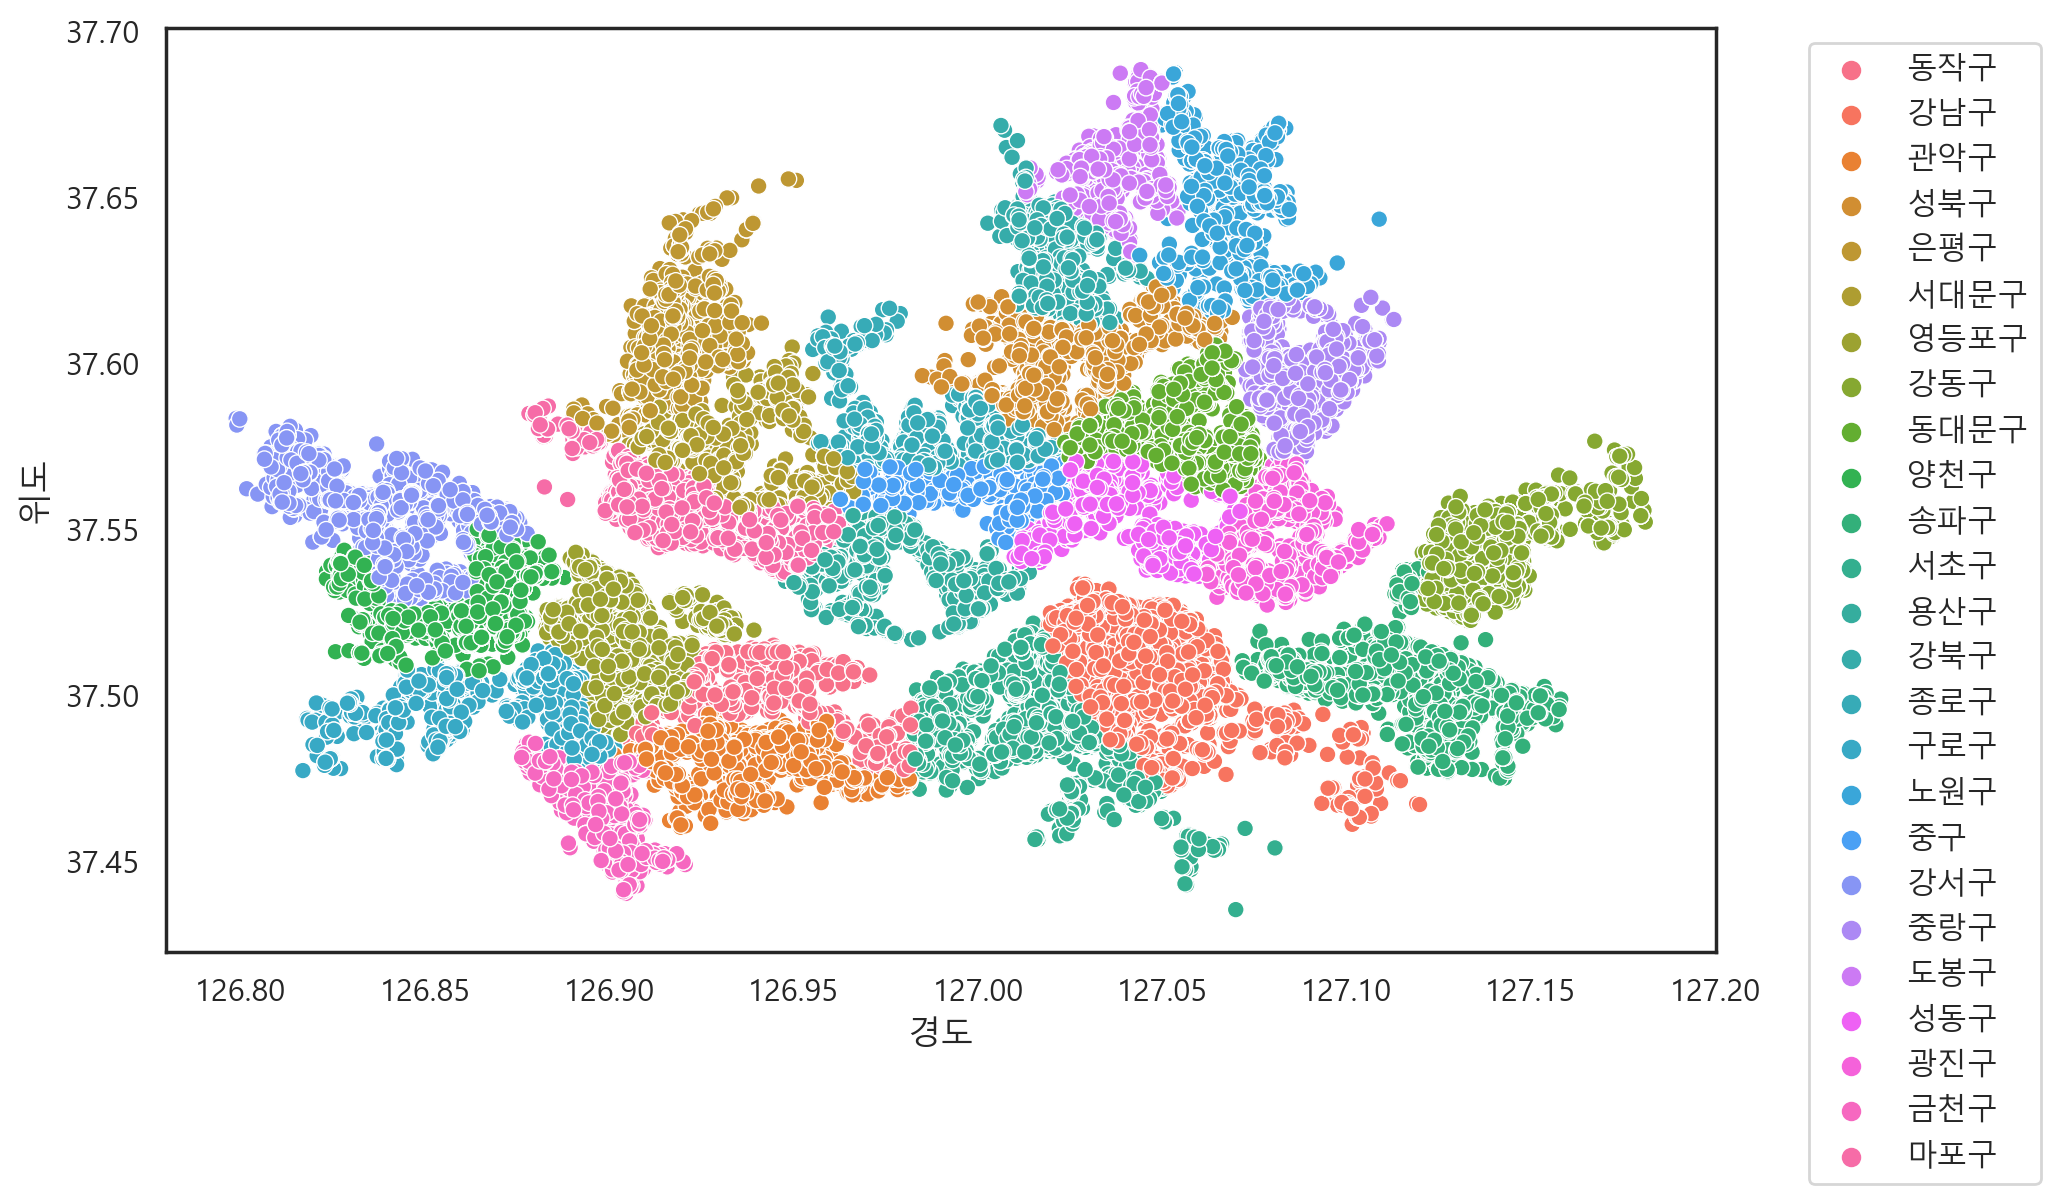

In [101]:
sns.scatterplot(data=df_academy,
               x='경도',
               y='위도',
               hue='시군구명')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot : 범례사용

## ② df_academy 데이터셋의 경도와 위도를 “상권업종소분류명”별로 색상을 다르게 scatterplot으로 시각화

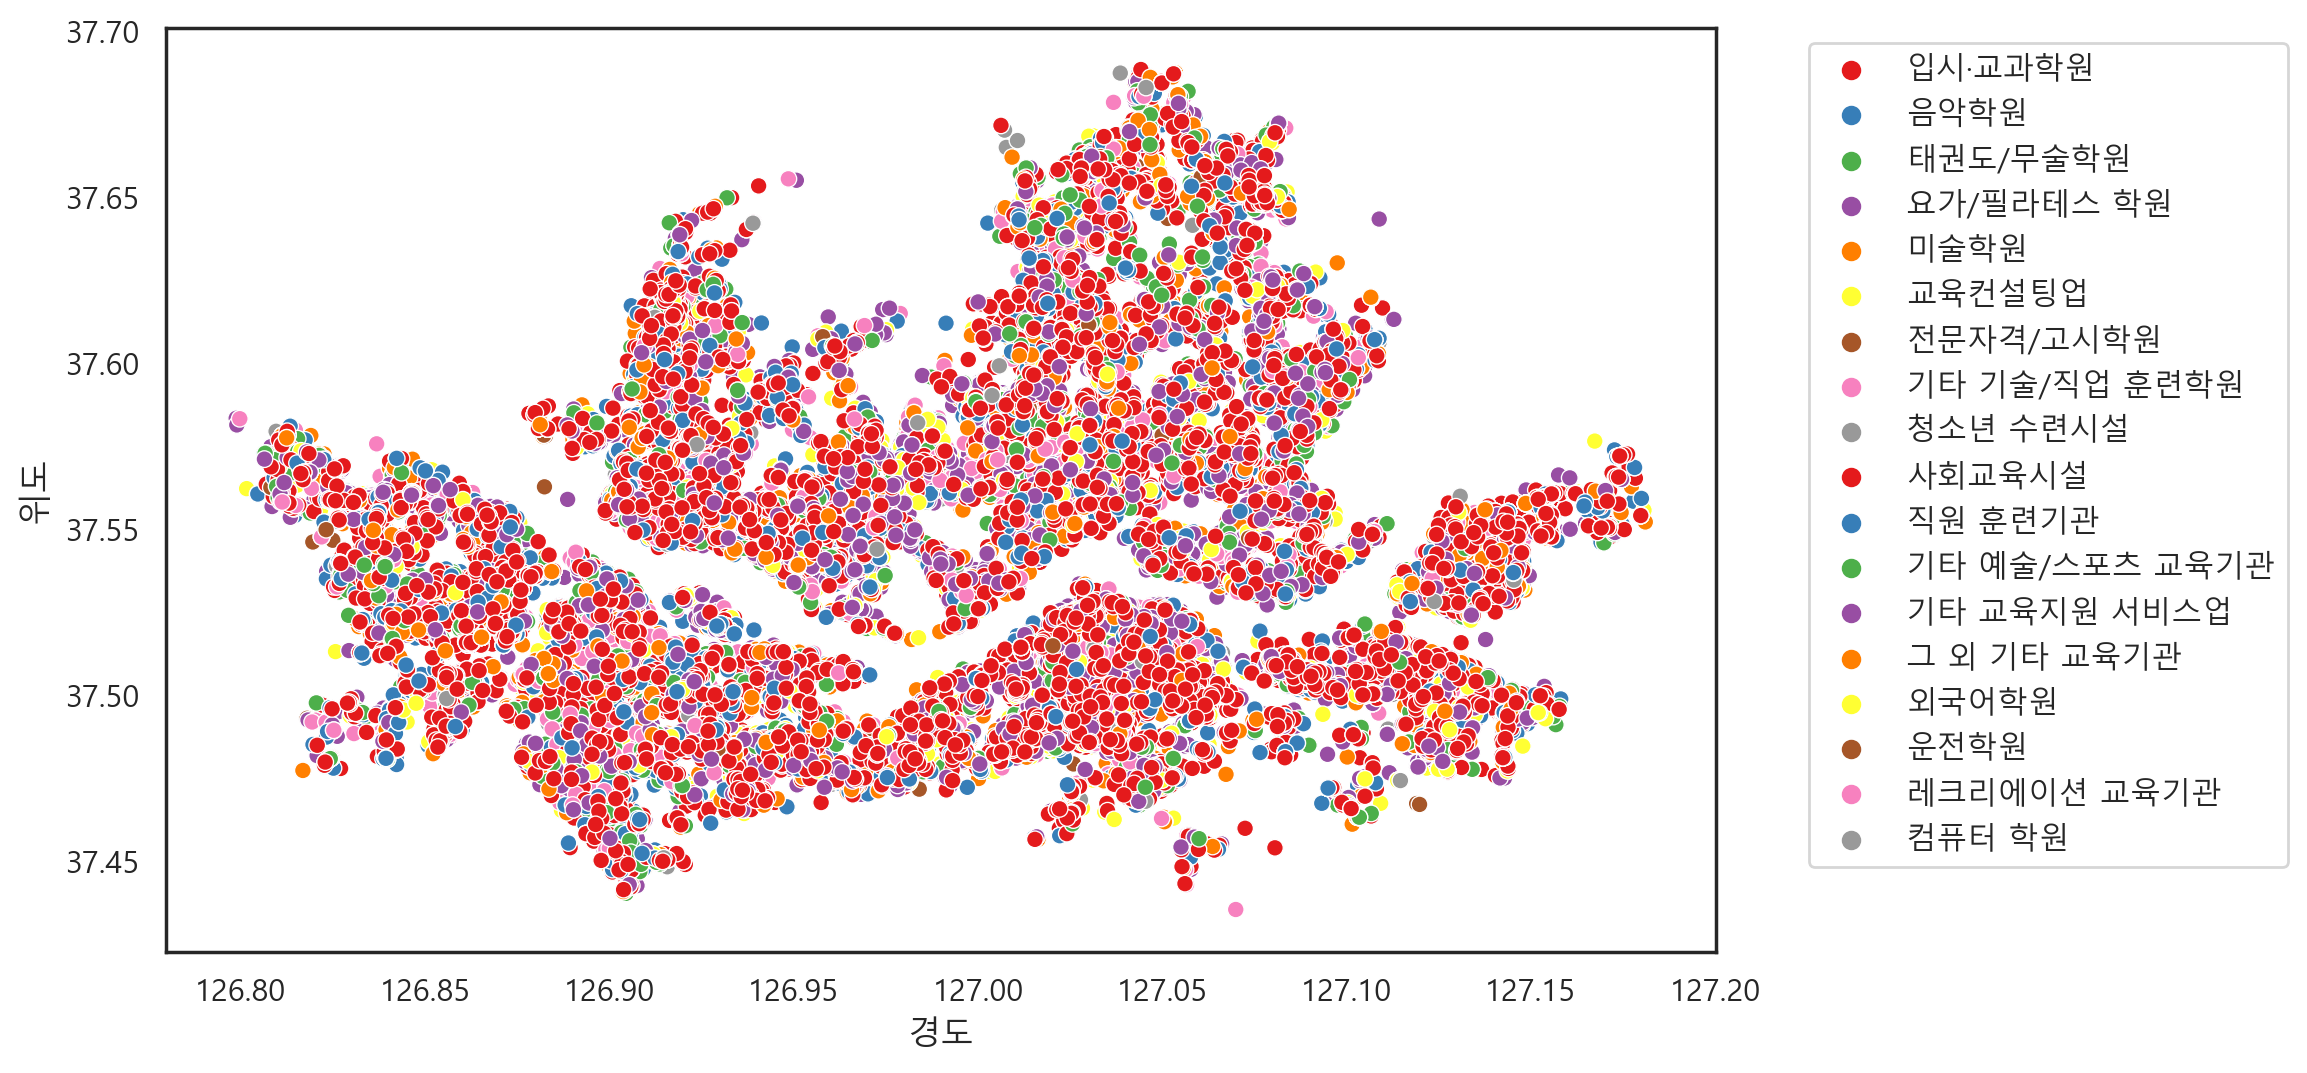

In [103]:
sns.scatterplot(data=df_academy,
               x='경도',
               y='위도',
               hue='상권업종소분류명', palette='Set1')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

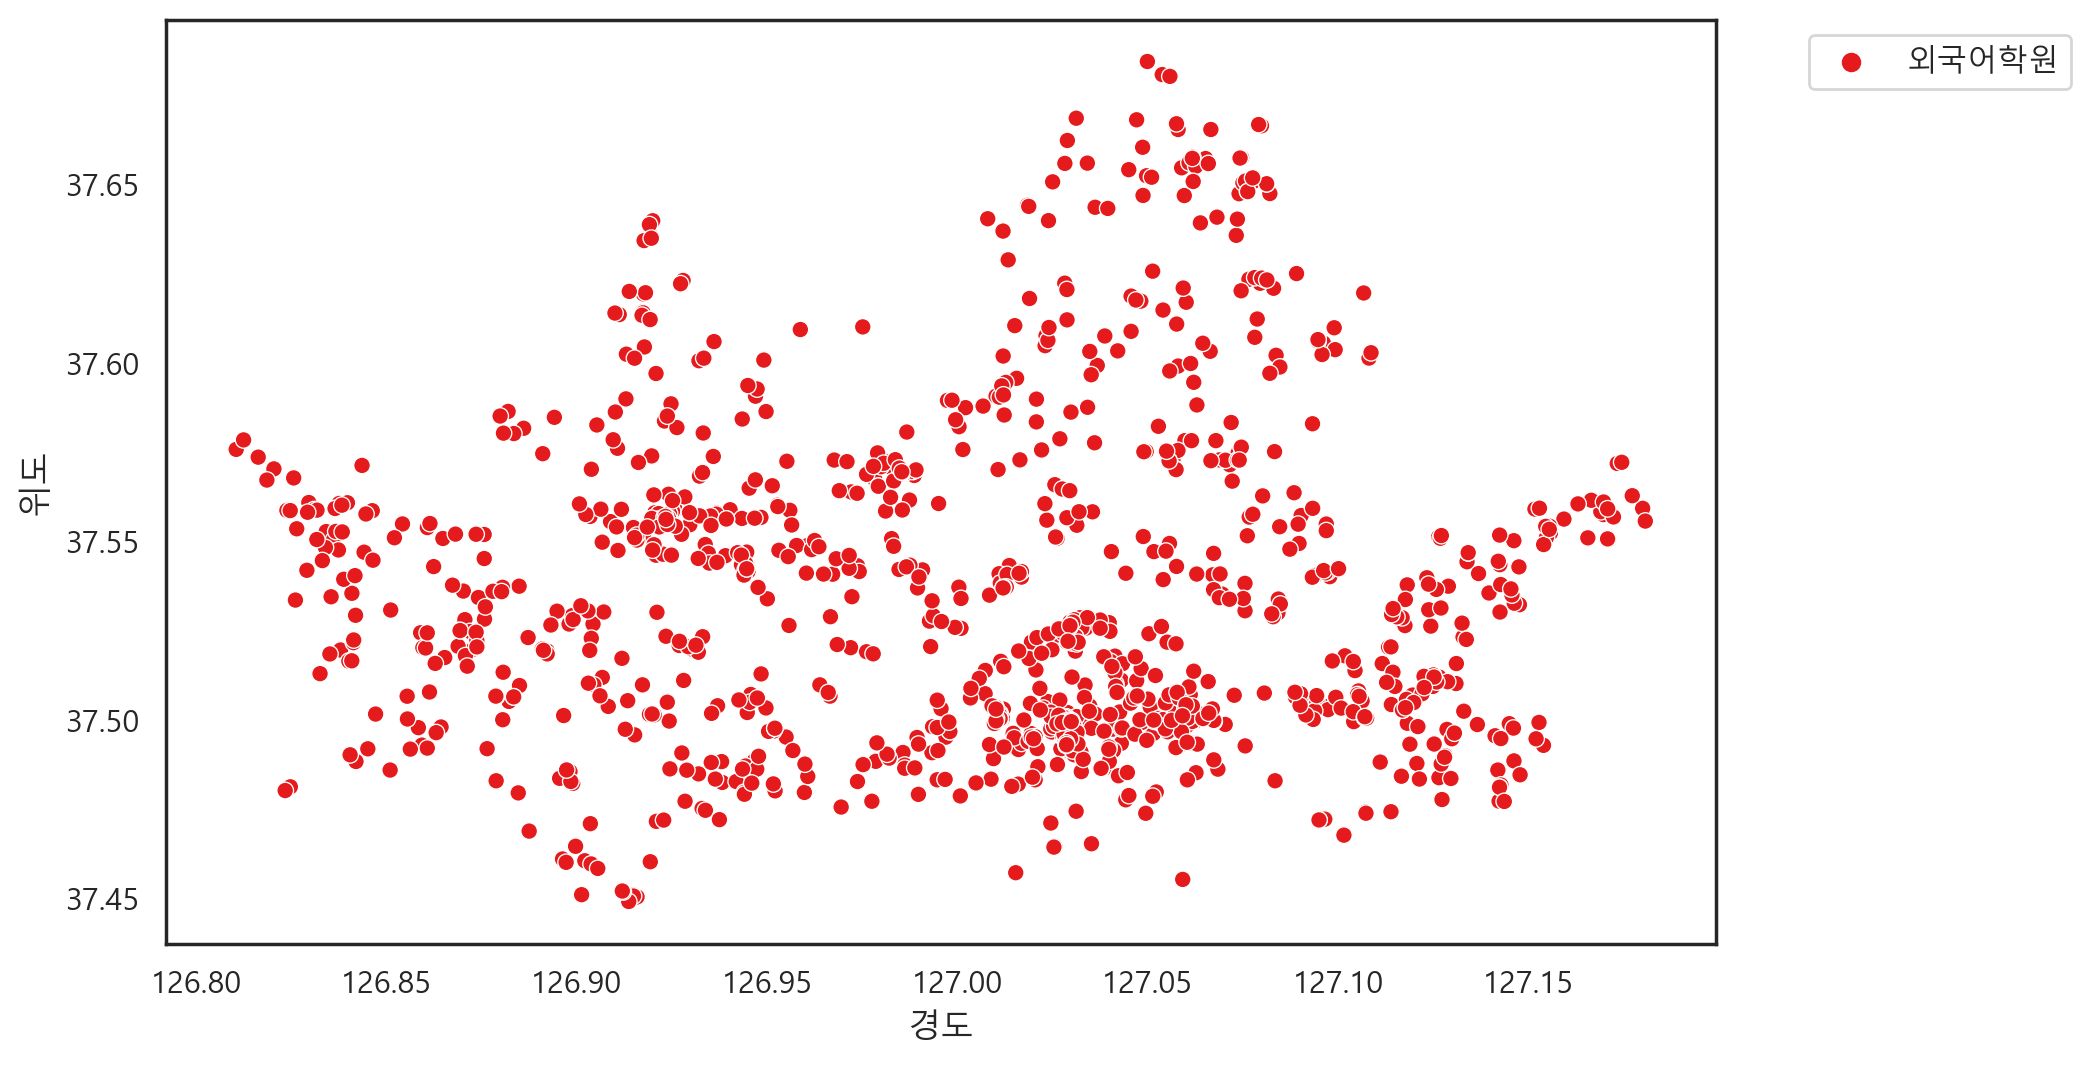

In [104]:
sns.scatterplot(data=df_academy[df_academy['상권업종소분류명']=='외국어학원'],
               x='경도',
               y='위도',
               hue='상권업종소분류명', palette='Set1')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [106]:
df_academy_sel['상권업종소분류명'].unique()

array(['입시·교과학원', '교육컨설팅업'], dtype=object)

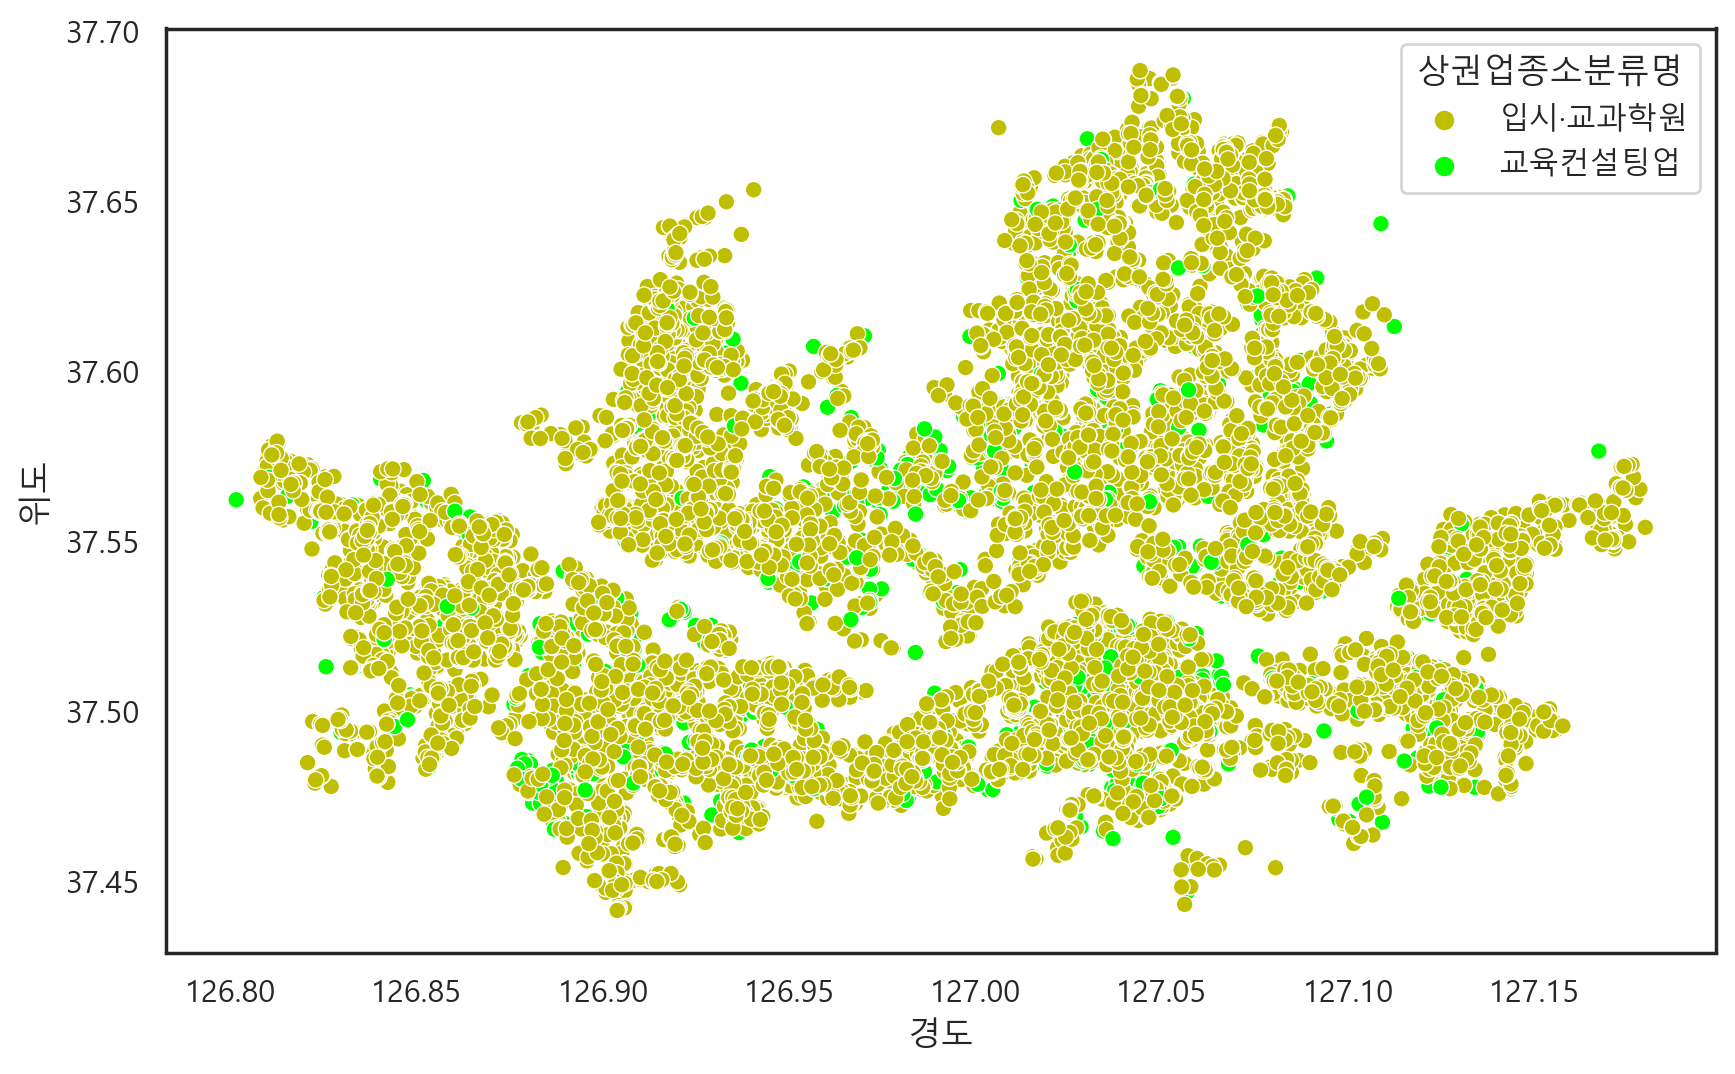

In [110]:
custom_palette = {'입시·교과학원':'y',
                  '교육컨설팅업':'#00ff00'}
sns.scatterplot(data=df_academy_sel,
               x="경도", y="위도", 
               hue='상권업종소분류명',
               palette=custom_palette)
plt.show()

## ③ df_academy 데이터셋 중 “입시·교과학원” 데이터만, 경도와 위도를 “시군구명”별로 색상을 다르게 scatterplot으로 시각화

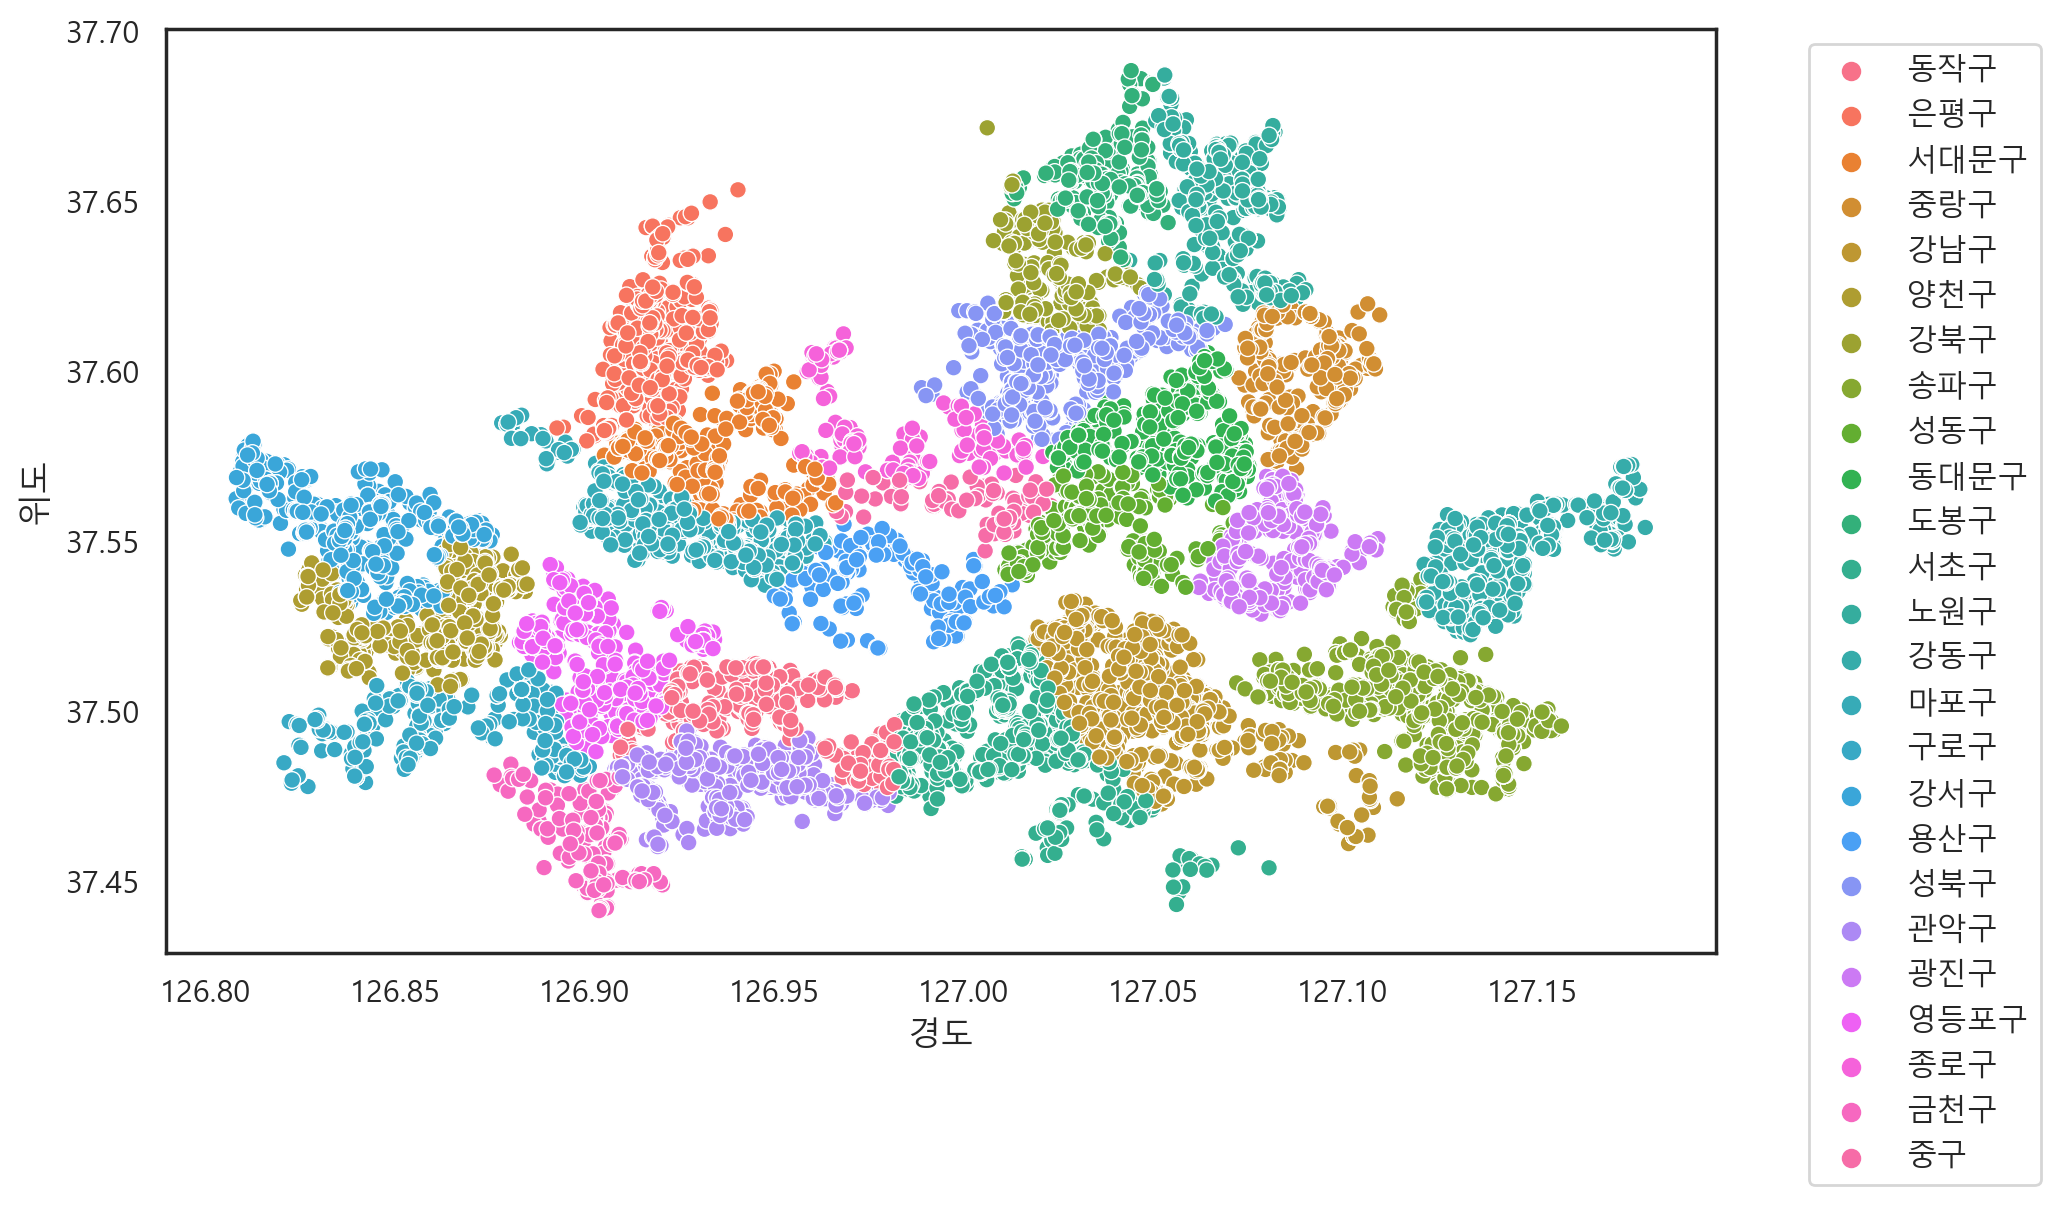

In [112]:
sns.scatterplot(data=df_academy[df_academy['상권업종소분류명']=='입시·교과학원'],
               x='경도',
               y='위도',
               hue='시군구명')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## ④ df_academy 데이터셋 중 “태권도/무술학원” 데이터만, 경도와 위도를 “시군명”별로 색상을 다르게 scatterplot으로 시각화

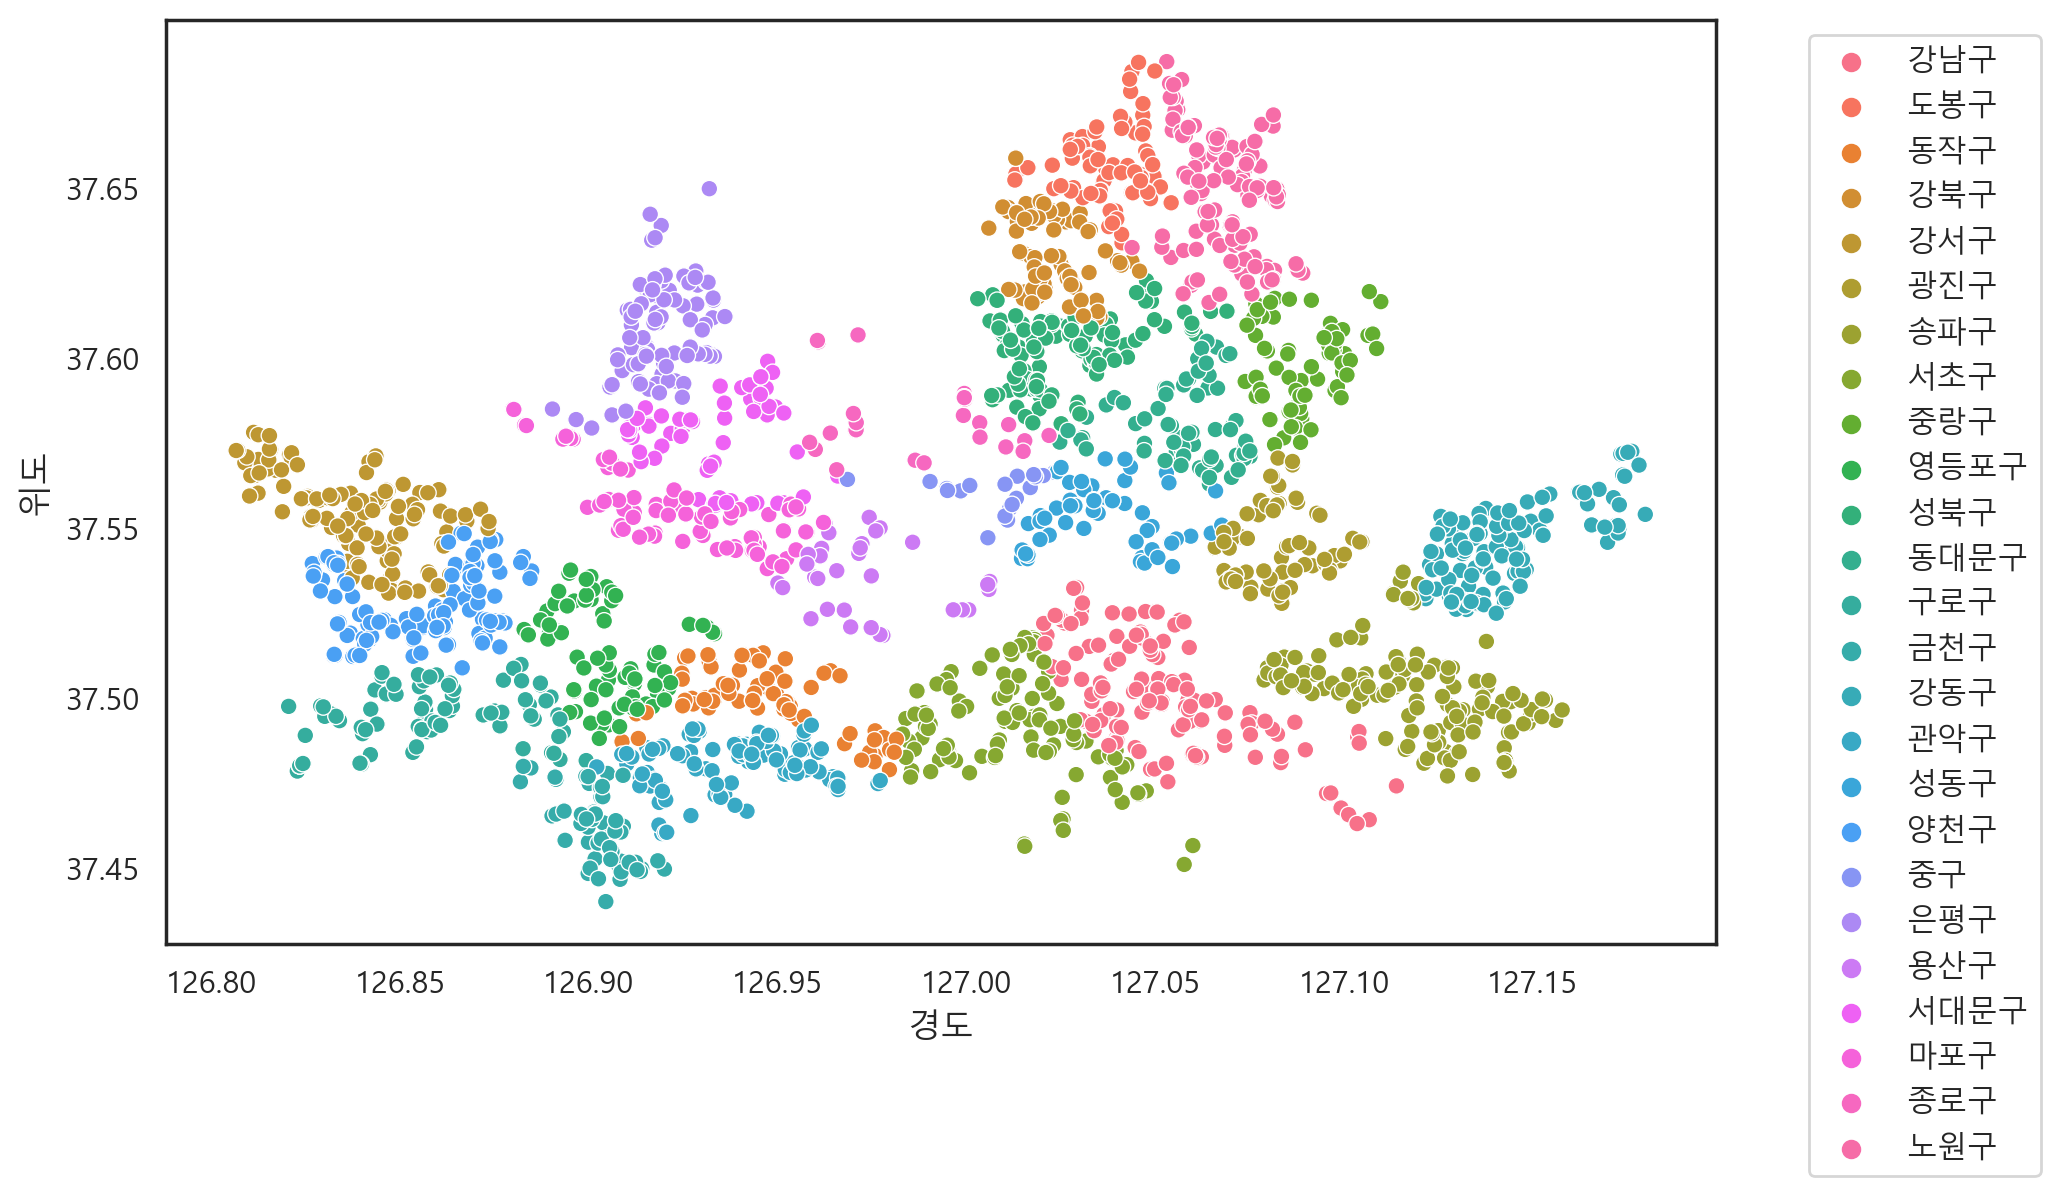

In [113]:
sns.scatterplot(data=df_academy[df_academy['상권업종소분류명']=='태권도/무술학원'],
               x='경도',
               y='위도',
               hue='시군구명')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## ⑤ df_academy 데이터셋 중 “입시·교과학원” 데이터와 “태권도/무술학원” 데이터만, 경도와 위도를 “상권업종소분류명”별로 색상을 다르게 scatterplot으로 시각화

In [116]:
df_academy[df_academy['상권업종소분류명'].isin(['입시·교과학원', '태권도/무술학원'])].shape

(19350, 17)

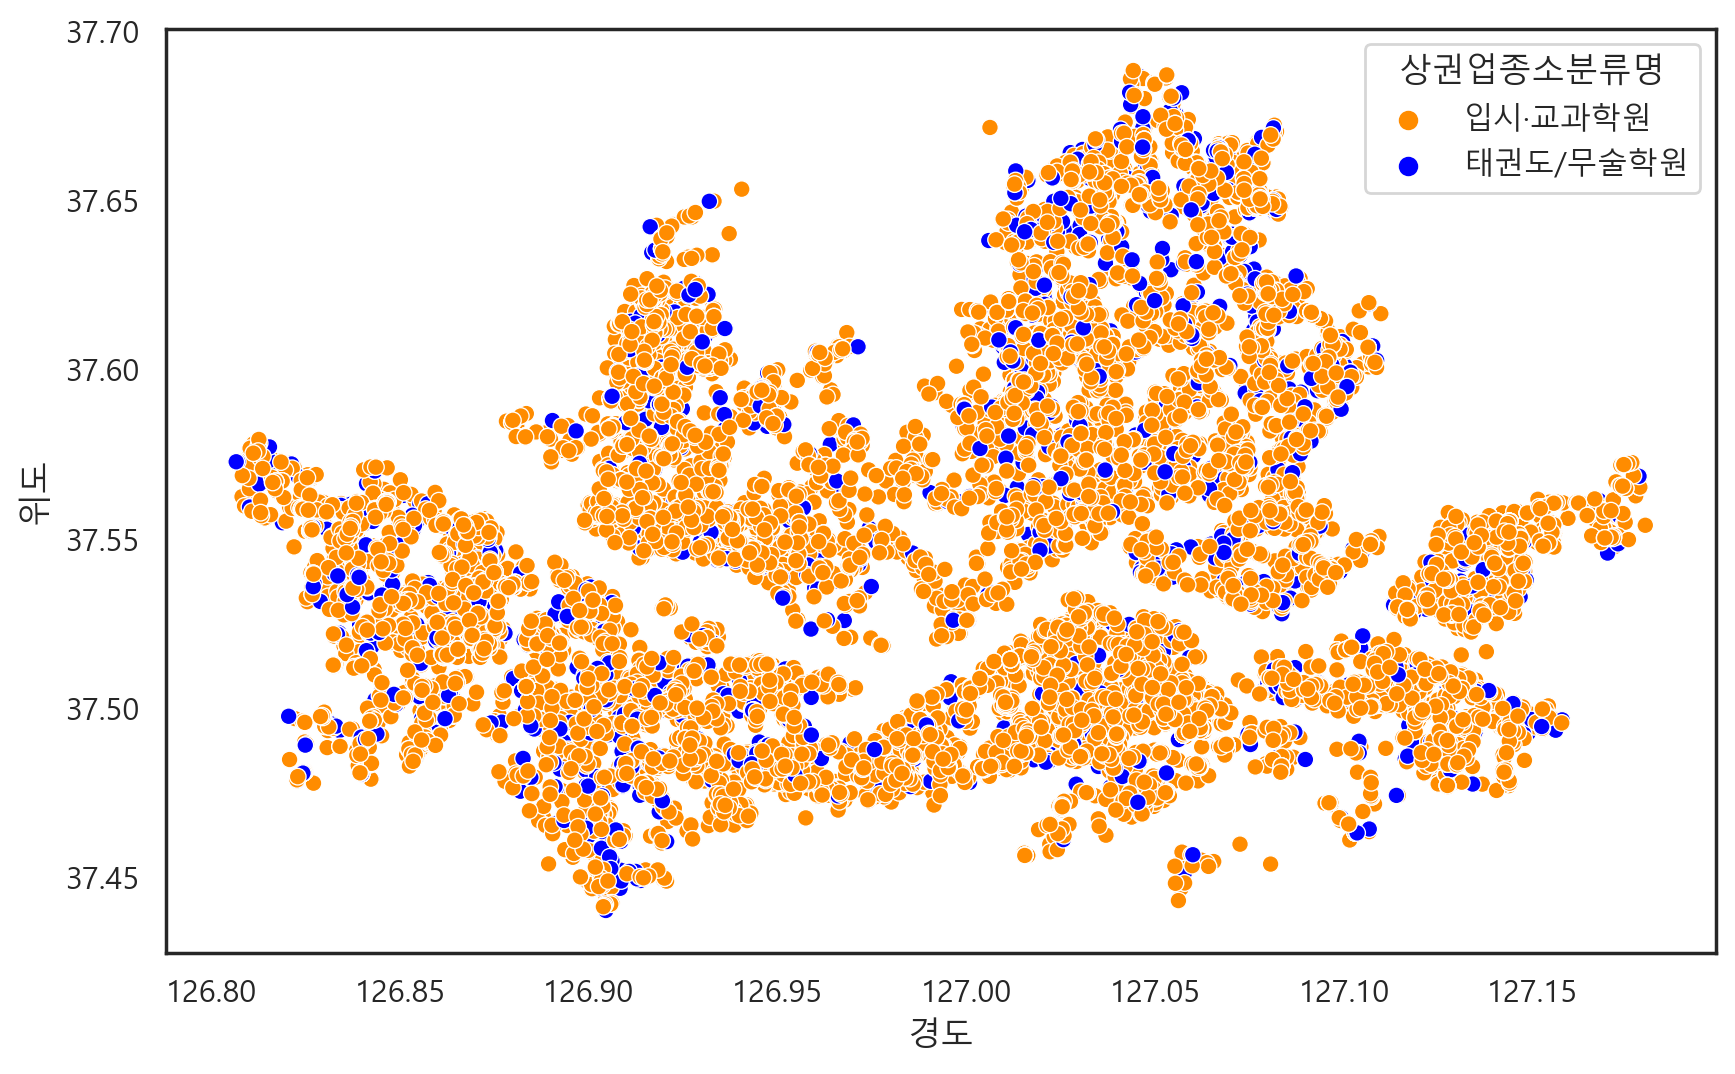

In [120]:
sns.scatterplot(data=df_academy[df_academy['상권업종소분류명'].isin(['입시·교과학원', '태권도/무술학원'])],
               x='경도', y='위도',
               hue='상권업종소분류명',
               palette=['darkorange', 'b'])
plt.show()

# 15. 지도시각화 : Folium
` 아나콘다 프롬프트에서 아래의 둘 중 하나를 실행`

`pip install folium`

`conda install -c conda-forge folium`

-	docs : https://python-visualization.github.io/folium/latest/getting_started.html?utm_source=chatgpt.com
-	Quickstart : https://python-visualization.github.io/folium/version-v0.9.1/quickstart.html?utm_source=chatgpt.com
- API reference : https://python-visualization.github.io/folium/latest/reference.html

In [121]:
import folium
folium.__version__

'0.20.0'

In [131]:
m = folium.Map(location=[45.5236, -122.6750],
              zoom_start=12,
              #width='90%',
              width=800,
              #height=400
               height='50%'
              )
m

In [136]:
# 상권업종소분류명이 태권도/무술학원과 입시·교과학원인데이터만
part = ['입시·교과학원','태권도/무술학원']
df_m = df_academy[df_academy['상권업종소분류명'].isin(part)].sample(1000, random_state=3)
df_m.shape

(1000, 17)

In [138]:
df_m.head().index

Int64Index([42228, 23228, 42006, 39801, 34219], dtype='int64')

In [149]:
# df_m을 지도시각화
lat_mean = df_m['위도'].mean()
long_mean = df_m['경도'].mean()
m = folium.Map(location=[lat_mean, long_mean],
              zoom_start=12,
              #tiles="cartodb positron"
              )
m

- 지도에 marker 추가하기

In [153]:
df_m.head(2)

,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,표준산업분류명,시도명,시군구명,행정동명,법정동명,대지구분명,지번본번지,지번주소,도로명,건물본번지,도로명주소,경도,위도
42228,리딩오션강동독서논술교습소,교육,일반 교육,입시·교과학원,일반 교과학원,서울특별시,강동구,성내1동,성내동,대지,545.0,서울특별시 강동구 성내동 545,서울특별시 강동구 성내로15길,10.0,서울특별시 강동구 성내로15길 10,127.128551,37.527806
23228,마운틴영어교습소,교육,일반 교육,입시·교과학원,일반 교과학원,서울특별시,동작구,사당3동,사당동,대지,162.0,서울특별시 동작구 사당동 162-96,서울특별시 동작구 사당로23나길,30.0,서울특별시 동작구 사당로23나길 30,126.975543,37.487698


In [156]:
display(df_m.loc[42228, ['상호명','도로명','위도','경도']])
display(df_m.loc[23228, ['상호명','도로명','위도','경도']])

상호명       리딩오션강동독서논술교습소
도로명    서울특별시 강동구 성내로15길
위도            37.527806
경도           127.128551
Name: 42228, dtype: object

상호명             마운틴영어교습소
도로명    서울특별시 동작구 사당로23나길
위도             37.487698
경도            126.975543
Name: 23228, dtype: object

In [163]:
m = folium.Map([lat_mean, long_mean], 
               zoom_start=12)

folium.Marker(
    location=[37.527806, 127.128551],
    tooltip="리딩오션강동독서논술교습소 - 강동구 성내로15길",
    icon=folium.Icon(icon="cloud"),
).add_to(m)

lat = df_m.loc[23228, '위도']
long = df_m.loc[23228, '경도']
tooltip = "<b>{} - {}</b>".format(df_m.loc[23228, '상호명'],
                                 df_m.loc[23228, '도로명'][6:])
folium.Marker(
    location=[lat, long],
    tooltip=tooltip, # 마우스 up시 나타나는 글씨
    # popup="Timberline Lodge", click후 나타나는 글씨
    icon=folium.Icon(color="green"),
).add_to(m)

m

In [174]:
for i in df_m[:10].index:
    print(df_m.loc[i, '상호명'], df_m.loc[i, '도로명'][6:], df_m.loc[i, '위도'], df_m.loc[i, '경도'])

리딩오션강동독서논술교습소 강동구 성내로15길 37.5278059885402 127.128551392731
마운틴영어교습소 동작구 사당로23나길 37.4876976095013 126.97554272704
피오르에듀 강남구 도곡로77길 37.4999485460077 127.058128022903
김태리 마포구 고산2길 37.5536648722227 126.939080234854
임팩트학원 광진구 자양로 37.547943768781 127.088945333273
정릉백상영수학원 성북구 정릉로26길 37.6040365796062 127.01156251141
에폴영어학원 강서구 공항대로55길 37.5544282495679 126.861477730045
성북스마트정일학원 성북구 동소문로 37.5923324776886 127.01368940918
마포서대문와이즈만 마포구 마포대로 37.5423079661221 126.948967775601
본스타컴퍼니 서초구 나루터로 37.5157291555181 127.017374210867


In [191]:
m = folium.Map([lat_mean, long_mean], 
               zoom_start=12)

for i in df_m.index:
    lat = df_m.loc[i, '위도']
    long = df_m.loc[i, '경도']
    tooltip = '<b>{} - {}</b>'.format(df_m.loc[i, '상호명'],
                                     df_m.loc[i, '도로명'][6:])
#     folium.Marker(
#         location=[lat, long],
#         tooltip=tooltip,
#         icon=folium.Icon(icon="cloud"),
#     ).add_to(m)
    folium.Circle(
        radius=100,
        location=[lat, long],
        tooltip=tooltip,
        color='crimson',
        fill=False,
    ).add_to(m)
m

In [187]:
# 태권도/무술학원과 입시·교과학원을 분리해서 지도 시각화
df1 = df_m[df_m['상권업종소분류명']=='태권도/무술학원']
df2 = df_m[df_m['상권업종소분류명']=='입시·교과학원']
print(df1.shape)
print(df2.shape)

(126, 17)
(874, 17)


In [192]:
m = folium.Map([lat_mean, long_mean], 
               zoom_start=12)

for i in df1.index:
    lat = df_m.loc[i, '위도']
    long = df_m.loc[i, '경도']
    tooltip = '<b>{} - {}</b>'.format(df_m.loc[i, '상호명'],
                                     df_m.loc[i, '도로명'][6:])
    folium.Circle(
        radius=100,
        location=[lat, long],
        tooltip=tooltip,
        color='red',
        fill=False,
    ).add_to(m)
    
for i in df2.index:
    lat = df_m.loc[i, '위도']
    long = df_m.loc[i, '경도']
    tooltip = '<b>{} - {}</b>'.format(df_m.loc[i, '상호명'],
                                     df_m.loc[i, '도로명'][6:])
    folium.Circle(
        radius=100,
        location=[lat, long],
        tooltip=tooltip,
        color='blue',
        fill=False,
    ).add_to(m)
m

In [194]:
m.save('ch13.html')